# 05 — Court judgment extraction (SC / COA), 3-stage pilot

The reported CommonLII cases carry an editor headnote, so notebook `04` recovers
their rules deterministically. The **unreported** Supreme Court / Court of Appeal
judgments under `data/legal-sources/library/case-law/courts/{sc,coa}` have **no
headnote** — nothing structured has been pulled from them yet. They are the
biggest coverage gap in the case-law corpus (~5,474 files).

This is a **10-file pilot** that proves the extraction design before scaling:

1. **Stage 1 — regex (free).** Pull the *envelope* metadata that sits in the text
   as literal, templated strings: `court`, `decision_date`, `judges`,
   `authoring_judge`, `cited_cases`, `statute_links`, and the `final_order`
   sentence.
2. **Stage 2 — conveyancing gate (free).** From the statute references + a
   land-law keyword pass, decide **conveyancing or not**. Only conveyancing
   cases go on to the paid LLM step. Non-conveyancing cases stop here with an
   auditable stub — nothing is silently dropped.
3. **Stage 3 — Gemini (paid, conveyancing cases only).** Fill the *meaning*
   fields regex cannot read off the page: `topics`, `questions_of_law`,
   `atomic_rules` (each grounded by a verbatim quote), `case_specific_findings`,
   and a normalised `final_order`.

The 10 files are a deliberate **test set** — 7 clear land cases, 1 borderline
state-land writ, 2 clearly non-land (labour, fundamental rights) — so the gate is
measured on precision *and* recall, not just easy hits.

Everything produced here is `status: "unverified"`: a lawyer signs off before any
rule is trusted. Nothing invented — quotes must appear verbatim in the source.

In [1]:
import json, os, re, sys, textwrap
from pathlib import Path
import pandas as pd

# repo root (works whether cwd is repo root or notebooks/)
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
print("repo root:", ROOT)

COURTS_ROOT = ROOT / "data" / "legal-sources" / "library" / "case-law" / "courts"
OUT_DIR = ROOT / "evaluation" / "runs" / "courts-extraction-pilot"
(OUT_DIR / "judgments").mkdir(parents=True, exist_ok=True)

# reuse the existing extraction utilities (grounding gate, windowing, catalogue)
EXTRACT_DIR = ROOT / "scripts" / "case-law-information-extraction"
sys.path.insert(0, str(EXTRACT_DIR))
import validate as V          # quote_match() grounding gate
import windowing              # build_window() focused extract
import catalogue              # statute-registry resolution

# The 10-file pilot set with hand-labelled gold verdicts (YES/NO/BORDERLINE).
PILOT = [
    {"rel": "coa/1095-99-f",            "gold": "YES",        "kind": "partition / prescription"},
    {"rel": "coa/17.-ca-889_2000f",     "gold": "YES",        "kind": "land declaration / possession"},
    {"rel": "coa/04.c.a-phc_182_2006",  "gold": "YES",        "kind": "land possession (Primary Courts s.66)"},
    {"rel": "coa/15.-ca-dcf-1058_2000", "gold": "YES",        "kind": "conditional transfer deed"},
    {"rel": "coa/13.-ca-836-99-f",      "gold": "YES",        "kind": "paper title vs prescription"},
    {"rel": "sc/sc_appeal_1_2016",      "gold": "YES",        "kind": "land declaration"},
    {"rel": "sc/sc_appeal_10_2013",     "gold": "YES",        "kind": "land case"},
    {"rel": "coa/01.c.a-writ-49-_2013", "gold": "BORDERLINE", "kind": "state-land writ / Art.140 + FR"},
    {"rel": "sc/sc_appeal_1_2005",      "gold": "NO",         "kind": "labour / employment termination"},
    {"rel": "sc/sc_59_60_61_63_2020",   "gold": "NO",         "kind": "fundamental rights / police transfers"},
]

def case_id(rel):
    return "courts-" + rel.replace("/", "-") + ".pdf"

print(f"{len(PILOT)} pilot files; base = {COURTS_ROOT.relative_to(ROOT)}")

repo root: d:\projects\Draftly-Project\draftly-research
10 pilot files; base = data\legal-sources\library\case-law\courts


## Load and clean

The PDF text extraction collapses page/line breaks into one long run, so we anchor
on labels, not line positions. Two real noise classes are handled: the ligature
filler `ﾾ` (where a hyphen broke, e.g. `Defendant￾Appellant`) is restored to
`-`, and page markers (`Page 3 of 5`) are stripped. Non-English spans (Unicode
Sinhala, and legacy-font transliteration that reads as ASCII gibberish) are
*flagged* but kept — they are body text, not corruption to delete.

In [2]:
def load_clean(rel):
    path = COURTS_ROOT / (rel + ".pdf.txt")
    raw = path.read_text(encoding="utf-8", errors="replace")
    has_sinhala = bool(re.search(r"[඀-෿]", raw))
    # legacy-font transliteration signature: latin words glued by ; = / mid-token
    has_legacy = bool(re.search(r"[a-z]{2}[;=][a-z]{2}", raw))
    t = raw.replace("ﾾ", "-").replace("�", " ")
    t = re.sub(r"Page\s+\d+\s+of\s+\d+", " ", t, flags=re.I)
    t = re.sub(r"\s+", " ", t).strip()
    return {"raw": raw, "clean": t, "chars": len(t),
            "has_sinhala": has_sinhala, "has_legacy_font": has_legacy}

records = []
for spec in PILOT:
    doc = load_clean(spec["rel"])
    records.append({"case_id": case_id(spec["rel"]),
                    "court_dir": spec["rel"].split("/")[0].upper(),
                    "gold": spec["gold"], "kind": spec["kind"], **doc})

pd.DataFrame([{"case_id": r["case_id"], "chars": r["chars"],
               "sinhala": r["has_sinhala"], "legacy_font": r["has_legacy_font"],
               "gold": r["gold"]} for r in records])

,case_id,chars,sinhala,legacy_font,gold
0,courts-coa-1095-99-f.pdf,11407,True,False,YES
1,courts-coa-17.-ca-889_2000f.pdf,21943,True,False,YES
2,courts-coa-04.c.a-phc_182_2006.pdf,6975,False,False,YES
3,courts-coa-15.-ca-dcf-1058_2000.pdf,27117,False,False,YES
4,courts-coa-13.-ca-836-99-f.pdf,27129,True,False,YES
5,courts-sc-sc_appeal_1_2016.pdf,25035,True,False,YES
6,courts-sc-sc_appeal_10_2013.pdf,8566,False,False,YES
7,courts-coa-01.c.a-writ-49-_2013.pdf,19600,False,True,BORDERLINE
8,courts-sc-sc_appeal_1_2005.pdf,15402,False,False,NO
9,courts-sc-sc_59_60_61_63_2020.pdf,48785,True,False,NO


## Stage 1 — regex envelope extraction

Each field has one tolerant, case-insensitive extractor, grounded on the label
variants actually seen in these files (`Before:`/`BEFORE:`, `Decided On :`/
`DECIDED ON:`, `– J`/`P.C., J.`, `Vs.`/`vs`). Recall is intentionally below 100 %
— a missed field is blank, never guessed.

In [3]:
# --- court -----------------------------------------------------------------
def x_court(text, court_dir):
    if re.search(r"IN THE SUPREME COURT", text, re.I):
        return "SC"
    if re.search(r"IN THE COURT OF APPEAL", text, re.I):
        return "COA"
    return court_dir  # fallback to the source directory

# --- decided-on date -------------------------------------------------------
_DATE = (r"(?:\d{1,2}[./\-]\d{1,2}[./\-]\d{2,4}"
         r"|\d{1,2}(?:st|nd|rd|th)?\s+[A-Za-z]+\s+\d{4})")
DECIDED = re.compile(r"\b(?:DECIDED|DELIVERED)\s*ON\s*[:\-]?\s*(" + _DATE + r")", re.I)
ARGUED  = re.compile(r"\bARGUED\s*ON\s*[:\-]?\s*(" + _DATE + r")", re.I)

_MONTHS = {m: i for i, m in enumerate(
    ["january","february","march","april","may","june","july","august",
     "september","october","november","december"], 1)}

def iso_date(s):
    if not s:
        return ""
    s = s.strip()
    m = re.match(r"(\d{1,2})[./\-](\d{1,2})[./\-](\d{2,4})", s)
    if m:
        d, mo, y = (int(x) for x in m.groups())
        y = y + 2000 if y < 100 else y
        return f"{y:04d}-{mo:02d}-{d:02d}"
    m = re.match(r"(\d{1,2})(?:st|nd|rd|th)?\s+([A-Za-z]+)\s+(\d{4})", s)
    if m and m.group(2).lower() in _MONTHS:
        d, mo, y = int(m.group(1)), _MONTHS[m.group(2).lower()], int(m.group(3))
        return f"{y:04d}-{mo:02d}-{d:02d}"
    return ""

def x_decided(text):
    m = DECIDED.search(text)
    if not m:
        return "", "", None
    return m.group(1), iso_date(m.group(1)), m.span()

# --- judges panel (BEFORE ... COUNSEL) -------------------------------------
BEFORE = re.compile(r"\bBEFORE\s*[:\-]?\s*(.*?)\s*\bCOUNSEL\b", re.I | re.S)
_NAME  = r"[A-Z][A-Za-z.'\-]*(?:\s+[A-Z][A-Za-z.'\-]*){0,4}"
JUDGE  = re.compile(_NAME + r"(?:\s*,?\s*P\.?\s*C\.?)?\s*,?\s*[–—-]?\s*J\b\.?")

def x_judges(text):
    m = BEFORE.search(text)
    if not m:
        return []
    block = m.group(1)
    names = [re.sub(r"\s+", " ", n).strip() for n in JUDGE.findall(block)]
    # de-dup, keep order
    seen, out = set(), []
    for n in names:
        if n.lower() not in seen:
            seen.add(n.lower()); out.append(n)
    return out

# --- authoring judge (name right after the DECIDED ON date, before the body)
def x_author(text, decided_span, judges):
    seg = text[decided_span[1]:decided_span[1] + 160] if decided_span else text[:200]
    seg = re.sub(r"^[\s\d.\-•,]+", "", seg)  # strip page nums / stray punct
    m = re.match(_NAME + r"(?:\s*,?\s*P\.?\s*C\.?)?\s*,?\s*[–—-]?\s*J\b\.?", seg)
    if m:
        return re.sub(r"\s+", " ", m.group(0)).strip()
    return judges[0] if judges else ""

# --- final order / disposition ---------------------------------------------
DISPO = [
    (r"appeal is allowed|appeal[^.]{0,25}allowed|allow the appeal", "allowed"),
    (r"appeal is dismissed|appeal[^.]{0,25}dismissed|dismiss the appeal", "dismissed"),
    (r"application is (?:accordingly )?dismissed|dismiss the application", "dismissed"),
    (r"we affirm|affirm the (?:judgment|order)|judgment[^.]{0,25}affirmed", "affirmed"),
    (r"set aside", "set-aside"),
    (r"\bquash", "quashed"),
    (r"remitted|sent back|re-?trial", "remitted"),
]
def x_final_order(text):
    tail = text[-1400:]
    signals = [lab for pat, lab in DISPO if re.search(pat, tail, re.I)]
    # the sentence carrying the first disposition cue
    sent = ""
    m = re.search(r"([^.]{0,160}(?:appeal|application|judgment|order)[^.]{0,120}"
                  r"(?:allowed|dismissed|affirm|set aside|quash)[^.]{0,60}\.)",
                  tail, re.I)
    if m:
        sent = re.sub(r"\s+", " ", m.group(1)).strip()
    return sent, sorted(set(signals))

# --- cited cases (law-report citations + nearby party context) -------------
CITE = re.compile(
    r"\(?\d{4}\)?\s*\(?\d{0,3}\)?\s*"
    r"(?:NLR|N\.L\.R\.|SLR|S\.?L\.?R\.?|Sri\s?L\.?\s?R\.?|SrLL\.?R\.?|"
    r"CWR|CLW|C\.?L\.?W\.?|Labour Law Journal|Ceylon Law Weekly)"
    r"\s*\.?\s*\d+", re.I)

def x_cited(text):
    out, seen = [], set()
    for m in CITE.finditer(text):
        cite = re.sub(r"\s+", " ", m.group(0)).strip()
        if cite.lower() in seen:
            continue
        seen.add(cite.lower())
        ctx = re.sub(r"\s+", " ", text[max(0, m.start() - 70):m.start()]).strip()
        pm = re.search(r"([A-Z][A-Za-z.&' ]+?\s+[Vv]s?\.?\s+[A-Z][A-Za-z.&' ]+?)\s*$", ctx)
        out.append({"citation": cite, "parties": pm.group(1).strip() if pm else ""})
    return out

# --- statute references (Section N of the <Act/Ordinance/Constitution>) -----
STAT = re.compile(
    r"(?:[Ss]ection|[Ss]ec\.?|[Ss]\.|Article|Art\.)\s*\d+[A-Za-z0-9()\.\-]*"
    r"(?:\s*(?:and|,|to)\s*\d+[A-Za-z0-9()\.\-]*)*"
    r"\s+of\s+the\s+[A-Z][A-Za-z0-9 ,()'\-]+?"
    r"(?:Act|Ordinance|Code|Constitution|Law)"
    r"(?:,?\s*No\.?\s*\d+\s*of\s*\d{4})?")
EXTRA_STAT = re.compile(r"\b(?:\d{1,2}(?:st|nd|rd|th)\s+Amendment(?:\s+to\s+the\s+Constitution)?"
                        r"|Ninth Schedule|Thirteenth Amendment)\b", re.I)

def x_statutes(text):
    out, seen = [], set()
    for m in list(STAT.finditer(text)) + list(EXTRA_STAT.finditer(text)):
        ref = re.sub(r"\s+", " ", m.group(0)).strip(" .,")
        key = ref.lower()
        if key in seen or len(ref) < 8:
            continue
        seen.add(key); out.append(ref)
    return out

# --- run stage 1 over all records ------------------------------------------
for r in records:
    t = r["clean"]
    raw_date, iso, span = x_decided(t)
    judges = x_judges(t)
    sent, sigs = x_final_order(t)
    r["envelope"] = {
        "court": x_court(t, r["court_dir"]),
        "decision_date": iso, "decision_date_raw": raw_date,
        "judges": judges,
        "authoring_judge": x_author(t, span, judges),
        "cited_cases": x_cited(t),
        "statute_refs": x_statutes(t),
        "final_order_raw": sent, "final_order_signals": sigs,
    }
print("Stage 1 complete.")

Stage 1 complete.


In [4]:
env_rows = []
for r in records:
    e = r["envelope"]
    env_rows.append({
        "case_id": r["case_id"].replace("courts-", ""),
        "court": e["court"], "decided": e["decision_date"] or "—",
        "authoring_judge": e["authoring_judge"] or "—",
        "#judges": len(e["judges"]), "#cited": len(e["cited_cases"]),
        "#statutes": len(e["statute_refs"]),
        "final_order": (", ".join(e["final_order_signals"]) or "—"),
    })
pd.set_option("display.max_colwidth", 40)
pd.DataFrame(env_rows)

,case_id,court,decided,authoring_judge,#judges,#cited,#statutes,final_order
0,coa-1095-99-f.pdf,COA,2022-02-08,C.P. Kirtisinghe – J,2,1,0,"affirmed, dismissed"
1,coa-17.-ca-889_2000f.pdf,COA,2022-01-06,"Prasantha De Silva, J.",2,2,2,"allowed, set-aside"
2,coa-04.c.a-phc_182_2006.pdf,COA,2019-03-08,Janak De Silva J.,2,3,1,dismissed
3,coa-15.-ca-dcf-1058_2000.pdf,COA,2022-03-28,"Prasantha De Silva, J.",2,1,4,"affirmed, dismissed"
4,coa-13.-ca-836-99-f.pdf,COA,2022-03-24,C.P. Kirtisinghe – J,1,0,2,affirmed
5,sc-sc_appeal_1_2016.pdf,SC,2026-03-03,M. Sampath K. B. Wijeratne J.,3,1,8,"allowed, set-aside"
6,sc-sc_appeal_10_2013.pdf,SC,2017-03-20,GOONERATNE J.,3,1,2,dismissed
7,coa-01.c.a-writ-49-_2013.pdf,COA,2019-03-01,"Arjuna Obeyesekere, J",1,0,5,"dismissed, quashed"
8,sc-sc_appeal_1_2005.pdf,SC,2016-12-08,GOONERATNE J.,3,7,0,"allowed, set-aside"
9,sc-sc_59_60_61_63_2020.pdf,SC,2026-05-27,"CJ MAHINDA SAMAYAWARDHENA, J",2,0,0,quashed


## Stage 2 — conveyancing gate

Two deterministic signals decide conveyancing-or-not:

- **Strong statute signals** — the closed land-law statute set (Partition Act,
  Prevention of Frauds / Registration of Documents / Notaries / Land Development /
  State Lands / Prescription Ordinances, Primary Courts Procedure Act, etc.). A
  single strong hit is decisive.
- **Lexicon signals** — land vocabulary (deed, partition, prescription,
  servitude, corpus, immovable property, land kachcheri, …) plus `/P` and `/L`
  lower-court case-number suffixes. Three or more distinct hits pass.

**Rule:** conveyancing if `strong ≥ 1` **or** `lexicon ≥ 3`. We also cross-check
the pre-computed statute→topic bridge (`case_topic_links.csv`) as corroboration.

In [5]:
STRONG_STATUTES = [
    r"Partition Act", r"Partition Law",
    r"Prevention of Frauds Ordinance",
    r"Registration of Documents Ordinance",
    r"Notaries Ordinance",
    r"Land Development Ordinance",
    r"State Lands? (?:\(Recovery of Possession\) )?Ordinance",
    r"State Lands? Ordinance",
    r"Primary Courts.{0,3} Procedure Act",
    r"Prescription Ordinance",
    r"Trusts Ordinance",
    r"Land Acquisition Act",
    r"Registration of Title Act",
    r"Condominium (?:Property )?Act", r"Apartment Ownership",
]
LEXICON = [
    r"\bdeed\b", r"transfer deed", r"conveyance", r"\bpartition\b", r"prescriptive",
    r"prescription", r"servitude", r"\beasement\b", r"\bmortgage\b", r"notar(?:y|ial)",
    r"immovable propert", r"\bcorpus\b", r"\bco-?owner", r"land kachcheri",
    r"fideicommiss", r"\bdonation\b", r"deed of gift", r"\blease\b",
    r"prescriptive title", r"paper title", r"\bdispossess", r"quiet possession",
    r"\bstate land", r"\blot\s*\d", r"\bplan no", r"\b/[PL]\b", r"\d+/[PL]\b",
]

def gate(text, statute_refs):
    joined = " ".join(statute_refs) + " " + text
    strong = sorted({re.search(p, joined, re.I).group(0)
                     for p in STRONG_STATUTES if re.search(p, joined, re.I)})
    lex = sorted({re.search(p, text, re.I).group(0).lower()
                  for p in LEXICON if re.search(p, text, re.I)})
    is_conv = len(strong) >= 1 or len(lex) >= 3
    return {"conveyancing": is_conv,
            "score": len(strong) * 3 + len(lex),
            "strong_statutes": strong, "lexicon_hits": lex}

# statute->topic bridge cross-check (corroboration only, not decisive)
bridge_ids = set()
bridge_path = ROOT / "data" / "processed" / "legal-case-index" / "case_topic_links.csv"
if bridge_path.exists():
    b = pd.read_csv(bridge_path, dtype=str).fillna("")
    id_col = next((c for c in b.columns if "case" in c.lower() and "id" in c.lower()), None)
    if id_col:
        bridge_ids = set(b[id_col])

for r in records:
    g = gate(r["clean"], r["envelope"]["statute_refs"])
    g["topic_bridge"] = r["case_id"] in bridge_ids
    r["gate"] = g
print(f"topic-bridge court ids loaded: {len(bridge_ids)}")

topic-bridge court ids loaded: 3023


In [6]:
gate_rows = []
for r in records:
    g = r["gate"]
    verdict = "YES" if g["conveyancing"] else "NO"
    match = "OK" if (verdict == r["gold"] or r["gold"] == "BORDERLINE") else "MISS"
    gate_rows.append({
        "case_id": r["case_id"].replace("courts-", ""), "gold": r["gold"],
        "verdict": verdict, "score": g["score"],
        "strong": ", ".join(s[:22] for s in g["strong_statutes"]) or "—",
        "#lexicon": len(g["lexicon_hits"]), "bridge": g["topic_bridge"],
        "agree": match,
    })
gdf = pd.DataFrame(gate_rows)
n_conv = sum(r["gate"]["conveyancing"] for r in records)
misses = (gdf["agree"] == "MISS").sum()
print(f"conveyancing: {n_conv}/{len(records)} pass the gate  |  gate-vs-gold disagreements: {misses}")
gdf

conveyancing: 8/10 pass the gate  |  gate-vs-gold disagreements: 0


,case_id,gold,verdict,score,strong,#lexicon,bridge,agree
0,coa-1095-99-f.pdf,YES,YES,15,Partition Act,12,False,OK
1,coa-17.-ca-889_2000f.pdf,YES,YES,5,Land Development Ordin,2,False,OK
2,coa-04.c.a-phc_182_2006.pdf,YES,YES,4,Primary Courts Procedu,1,False,OK
3,coa-15.-ca-dcf-1058_2000.pdf,YES,YES,4,—,4,False,OK
4,coa-13.-ca-836-99-f.pdf,YES,YES,8,—,8,True,OK
5,sc-sc_appeal_1_2016.pdf,YES,YES,11,"Land Development Ordin, Registration...",5,True,OK
6,sc-sc_appeal_10_2013.pdf,YES,YES,12,Prescription Ordinance,9,True,OK
7,coa-01.c.a-writ-49-_2013.pdf,BORDERLINE,YES,6,Land Development Ordin,3,False,OK
8,sc-sc_appeal_1_2005.pdf,NO,NO,0,—,0,False,OK
9,sc-sc_59_60_61_63_2020.pdf,NO,NO,0,—,0,False,OK


## Stage 3 — Gemini meaning extraction (conveyancing cases only)

Only cases that pass the gate reach the LLM. Gemini returns a schema-constrained
JSON record; every `atomic_rules[].supporting_quote` is then checked against the
source with the existing grounding gate (`validate.quote_match`) and **dropped if
it is not present verbatim/near-verbatim** — the model cannot invent a rule that
isn't in the judgment. Statute references are resolved against the closed registry
where possible.

If `GEMINI_API_KEY` is absent (or a call fails) the notebook degrades gracefully:
the envelope + gate output is kept and the meaning fields are marked pending, so
the notebook always runs clean.

In [7]:
JUDGMENT_SCHEMA = {
    "type": "object",
    "properties": {
        "topics": {"type": "array", "items": {"type": "string"}},
        "questions_of_law": {"type": "array", "items": {"type": "string"}},
        "atomic_rules": {"type": "array", "items": {
            "type": "object",
            "properties": {
                "statement": {"type": "string"},
                "supporting_quote": {"type": "string"},
                "scope": {"type": "string", "enum": ["ratio", "obiter", "fact-specific"]},
            },
            "required": ["statement", "supporting_quote", "scope"],
        }},
        "case_specific_findings": {"type": "array", "items": {"type": "string"}},
        "final_order": {"type": "string"},
    },
    "required": ["topics", "questions_of_law", "atomic_rules",
                 "case_specific_findings", "final_order"],
}

SYS_JUDGMENT = (
    "You extract structured data from a Sri Lankan land / conveyancing judgment "
    "for a citation database. Return JSON only.\n"
    "- topics: short land-law topic tags (e.g. 'prescription', 'partition', "
    "'servitude', 'title').\n"
    "- questions_of_law: the legal questions the court actually decided, one per "
    "item, in plain words.\n"
    "- atomic_rules: each is ONE legal rule (ratio) the court itself states, with "
    "a 'supporting_quote' copied VERBATIM from the text (THIS court's own words, "
    "not a quotation of another case, not counsel's submission). If a rule has no "
    "verbatim support, omit it. Abstaining is correct when the case sets no rule.\n"
    "- case_specific_findings: findings tied to these facts (not general rules).\n"
    "- final_order: the disposition in a few words (e.g. 'Appeal dismissed; High "
    "Court judgment affirmed').\n"
    "Use only the provided text. Do not invent citations or statutes."
)

def gemini_extract(text, model, client, types):
    prompt = f'JUDGMENT TEXT:\n"""{windowing.build_window(text)}"""'
    last = None
    for attempt in range(3):
        try:
            resp = client.models.generate_content(
                model=model, contents=prompt,
                config=types.GenerateContentConfig(
                    system_instruction=SYS_JUDGMENT,
                    response_mime_type="application/json",
                    response_json_schema=JUDGMENT_SCHEMA,
                ),
            )
            return json.loads(resp.text)
        except Exception as e:  # noqa: BLE001 - degrade, never fail the notebook
            last = e
    raise last

# resolve a free-text statute name to a registry source_id (best-effort)
def resolve_statute(ref):
    reg = catalogue._registry()
    low = ref.lower()
    sec = ""
    ms = re.search(r"(?:section|s\.|article|art\.)\s*(\d+[A-Za-z0-9()]*)", ref, re.I)
    if ms:
        sec = ms.group(1)
    best = ""
    for sid, row in reg.items():
        title = (row.get("official_title") or "").lower()
        # match on the distinctive statute name (drop the "section N of the")
        name = re.sub(r"^.*?\bof the\b", "", low).strip() or low
        if title and (title in low or name in title) and len(name) > 6:
            best = sid
            break
    grounded = bool(best) and catalogue.valid_source(best)
    return {"verbatim": ref, "source_id": best if grounded else "",
            "section": sec, "grounded": grounded}

In [8]:
# --- run Stage 3 -----------------------------------------------------------
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")
API_KEY = os.getenv("GEMINI_API_KEY", "")
MODEL = os.getenv("DRAFTLY_GEMINI_MODEL", "gemini-3.5-flash")

client = types = None
if API_KEY:
    try:
        from google import genai
        from google.genai import types as _types
        client, types = genai.Client(api_key=API_KEY), _types
        print(f"Gemini enabled: model={MODEL}")
    except Exception as e:  # noqa: BLE001
        print(f"Gemini import failed, degrading: {e}")
else:
    print("GEMINI_API_KEY not set -> Stage 3 degrades (envelope + gate only).")

for r in records:
    if not r["gate"]["conveyancing"]:
        r["meaning"] = {"status": "skipped-not-conveyancing"}
        continue
    if client is None:
        r["meaning"] = {"status": "pending (no GEMINI_API_KEY)",
                        "topics": [], "questions_of_law": [], "atomic_rules": [],
                        "case_specific_findings": [], "final_order": ""}
        continue
    try:
        data = gemini_extract(r["clean"], MODEL, client, types)
    except Exception as e:  # noqa: BLE001
        msg = re.sub(r"\s+", " ", str(e))[:120]
        r["meaning"] = {"status": f"error: {type(e).__name__}: {msg}",
                        "topics": [], "questions_of_law": [], "atomic_rules": [],
                        "case_specific_findings": [], "final_order": ""}
        continue
    # grounding gate: keep only rules whose quote is really in the text
    kept, dropped = [], 0
    for rule in data.get("atomic_rules", []):
        mt = V.quote_match(rule.get("supporting_quote", ""), r["clean"])
        if mt is None:
            dropped += 1
            continue
        rule["quote_match"] = mt
        rule["confidence"] = "high" if mt == "verbatim" else "medium"
        kept.append(rule)
    r["meaning"] = {
        "status": "extracted",
        "topics": data.get("topics", []),
        "questions_of_law": data.get("questions_of_law", []),
        "atomic_rules": kept, "rules_dropped_ungrounded": dropped,
        "case_specific_findings": data.get("case_specific_findings", []),
        "final_order": data.get("final_order", ""),
        "statute_links": [resolve_statute(s) for s in r["envelope"]["statute_refs"]],
    }
    print(f"  {r['case_id']}: {len(kept)} grounded rules "
          f"(+{dropped} dropped), {len(r['meaning']['topics'])} topics")
print("Stage 3 complete.")

Gemini enabled: model=gemini-3.5-flash
Stage 3 complete.


## Assemble the target record

Merge all three stages into the user-supplied schema, per case. Non-conveyancing
cases carry the envelope + gate result and stop there.

In [9]:
def assemble(r):
    e = r["envelope"]
    m = r.get("meaning", {})
    rec = {
        "case_id": r["case_id"],
        "court": e["court"],
        "decision_date": e["decision_date"],
        "judges": e["judges"],
        "authoring_judge": e["authoring_judge"],
        "topics": m.get("topics", []),
        "questions_of_law": m.get("questions_of_law", []),
        "atomic_rules": m.get("atomic_rules", []),
        "case_specific_findings": m.get("case_specific_findings", []),
        "cited_cases": e["cited_cases"],
        "statute_links": m.get("statute_links",
                               [{"verbatim": s, "source_id": "", "section": "", "grounded": False}
                                for s in e["statute_refs"]]),
        "final_order": m.get("final_order") or e["final_order_raw"],
        "_conveyancing": r["gate"]["conveyancing"],
        "_gate_score": r["gate"]["score"],
        "_stage3_status": m.get("status", "n/a"),
        "status": "unverified",
    }
    return rec

assembled = [assemble(r) for r in records]
print(json.dumps(assembled[0], indent=2, ensure_ascii=False)[:1500], "...")

{
  "case_id": "courts-coa-1095-99-f.pdf",
  "court": "COA",
  "decision_date": "2022-02-08",
  "judges": [
    "C.P. Kirtisinghe – J",
    "Mayadunne Corea – J"
  ],
  "authoring_judge": "C.P. Kirtisinghe – J",
  "topics": [],
  "questions_of_law": [],
  "atomic_rules": [],
  "case_specific_findings": [],
  "cited_cases": [
    {
      "citation": "1994 (2) SLR 365",
      "parties": "Sirajudeen and two others Vs. Abbas"
    }
  ],
  "statute_links": [],
  "final_order": "",
  "_conveyancing": true,
  "_gate_score": 15,
  "_stage3_status": "error: ClientError: 401 UNAUTHENTICATED. {'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth ",
  "status": "unverified"
} ...


## Visualise

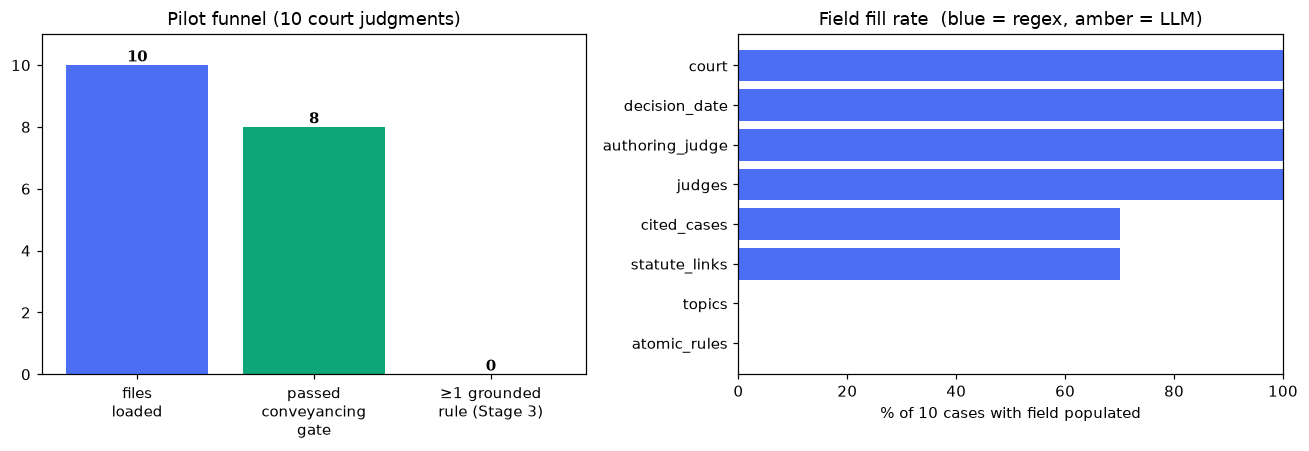

In [10]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

n_total = len(records)
n_conv = sum(a["_conveyancing"] for a in assembled)
n_rules = sum(1 for a in assembled if a["atomic_rules"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# funnel
stages = ["files\nloaded", "passed\nconveyancing\ngate", "≥1 grounded\nrule (Stage 3)"]
vals = [n_total, n_conv, n_rules]
bars = ax1.bar(stages, vals, color=["#4C6EF5", "#0CA678", "#F59F00"])
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.12, str(v), ha="center", fontweight="bold")
ax1.set_title("Pilot funnel (10 court judgments)")
ax1.set_ylim(0, n_total + 1)

# per-field fill rate
fields = ["court", "decision_date", "authoring_judge", "judges",
          "cited_cases", "statute_links", "topics", "atomic_rules"]
def filled(a, f):
    v = a[f]
    return bool(v) if not isinstance(v, list) else len(v) > 0
rate = [sum(filled(a, f) for a in assembled) / n_total * 100 for f in fields]
colors = ["#4C6EF5"]*6 + ["#F59F00"]*2  # regex vs LLM fields
ax2.barh(fields[::-1], rate[::-1], color=colors[::-1])
ax2.set_xlim(0, 100); ax2.set_xlabel("% of 10 cases with field populated")
ax2.set_title("Field fill rate  (blue = regex, amber = LLM)")
plt.tight_layout(); plt.show()

In [11]:
# record cards: one conveyancing case with rules, one gate-rejected case
def card(a):
    print("=" * 78)
    print(f"{a['case_id']}   [{a['court']}]   decided {a['decision_date'] or '—'}")
    print(f"conveyancing={a['_conveyancing']} (score {a['_gate_score']}) | "
          f"stage3={a['_stage3_status']} | status={a['status']}")
    print(f"authoring judge : {a['authoring_judge'] or '—'}")
    print(f"panel           : {', '.join(a['judges']) or '—'}")
    print(f"cited cases     : {len(a['cited_cases'])}  "
          + (", ".join(c['citation'] for c in a['cited_cases'][:4])))
    print(f"statutes        : "
          + (", ".join(s['verbatim'][:48] for s in a['statute_links'][:3]) or "—"))
    print(f"final order     : {a['final_order'] or '—'}")
    if a["topics"]:
        print(f"topics          : {', '.join(a['topics'])}")
    for i, rule in enumerate(a["atomic_rules"][:3], 1):
        print(f"  rule {i} [{rule.get('scope','?')}/{rule.get('quote_match','?')}]: "
              + textwrap.shorten(rule['statement'], 90))
        print("        quote: " + textwrap.shorten(rule['supporting_quote'], 90))

conv = next((a for a in assembled if a["atomic_rules"]),
            next((a for a in assembled if a["_conveyancing"]), assembled[0]))
rej = next((a for a in assembled if not a["_conveyancing"]), assembled[-1])
card(conv)
card(rej)

courts-coa-1095-99-f.pdf   [COA]   decided 2022-02-08
conveyancing=True (score 15) | stage3=error: ClientError: 401 UNAUTHENTICATED. {'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth  | status=unverified
authoring judge : C.P. Kirtisinghe – J
panel           : C.P. Kirtisinghe – J, Mayadunne Corea – J
cited cases     : 1  1994 (2) SLR 365
statutes        : —
final order     : —
courts-sc-sc_appeal_1_2005.pdf   [SC]   decided 2016-12-08
conveyancing=False (score 0) | stage3=skipped-not-conveyancing | status=unverified
authoring judge : GOONERATNE J.
panel           : B.P. Aluwihare P.C., J., Anil Gooneratne J., Prasanna S. Jayawardena P.C., J
cited cases     : 7  1995 1 SLR 261, 1996 1 SLR 334, (1962) 63 NLR 164, (1921) 8 CWR 240
statutes        : —
final order     : Appeal allowed without costs.


## Export

Per-case JSON records (target schema) and a `review-sample.csv` with blank verdict
columns for a lawyer to sign off. The run directory is gitignored.

In [12]:
for a in assembled:
    (OUT_DIR / "judgments" / (a["case_id"] + ".json")).write_text(
        json.dumps(a, indent=2, ensure_ascii=False), encoding="utf-8")

review_rows = []
for a in assembled:
    for i, rule in enumerate(a["atomic_rules"]):
        review_rows.append({
            "case_id": a["case_id"], "rule_index": i,
            "court": a["court"], "authoring_judge": a["authoring_judge"],
            "statement": rule["statement"], "supporting_quote": rule["supporting_quote"],
            "scope": rule.get("scope", ""), "quote_match": rule.get("quote_match", ""),
            # blank columns = the lawyer's gate
            "verdict_is_rule": "", "verdict_grounded": "", "reviewer_note": "",
        })
review = pd.DataFrame(review_rows)
review.to_csv(OUT_DIR / "review-sample.csv", index=False, encoding="utf-8")

meta_rows = [{"case_id": a["case_id"], "court": a["court"],
              "conveyancing": a["_conveyancing"], "gate_score": a["_gate_score"],
              "stage3": a["_stage3_status"], "n_rules": len(a["atomic_rules"]),
              "n_cited": len(a["cited_cases"]), "n_statutes": len(a["statute_links"])}
             for a in assembled]
pd.DataFrame(meta_rows).to_csv(OUT_DIR / "case_summary.csv", index=False, encoding="utf-8")

print(f"wrote {len(assembled)} judgment JSONs -> {OUT_DIR.relative_to(ROOT)}/judgments/")
print(f"wrote review-sample.csv ({len(review)} rules) and case_summary.csv")

wrote 10 judgment JSONs -> evaluation\runs\courts-extraction-pilot/judgments/
wrote review-sample.csv (0 rules) and case_summary.csv


## What this pilot shows

- **Regex owns the envelope.** `court`, `decision_date`, `judges`,
  `authoring_judge`, `cited_cases`, and `statute_links` come straight off the text
  for free — no model, fully auditable.
- **The gate is cheap and it discriminates.** Land cases pass on a single strong
  statute hit; the labour and fundamental-rights cases are filtered out before any
  paid call. The borderline state-land writ is the one to watch — it passes on the
  Land Development Ordinance, which is defensible but is exactly where a human
  should confirm.
- **The LLM is spent only where it earns its keep**, and every rule it returns is
  pinned to a verbatim quote or discarded.

**Next:** run the gate across all ~5,474 SC/COA files to size the real
conveyancing subset, hand `review-sample.csv` to a lawyer, then scale Stage 3 over
the confirmed set.